In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy.random as rnd
import os 
from scipy.special import loggamma, gamma, digamma


# K-Armed bandits


## Introduction to the problem
We have an agent aiming to solve a k-armed bandits problem. We can imagine the problem as a slot machine with k levers. Pulling one of them gives out the highest amount of cash. We want our agent to be able to get the highest amount of rewards on the long run. We consider the following setting: we extract 10 numbers from a standard normal distribution. These numbers will represent the average Reward given by each slot machine, according to a gaussian distributions with fixed variance 1. Notably, the problem can be generalized to any kind of distribution.

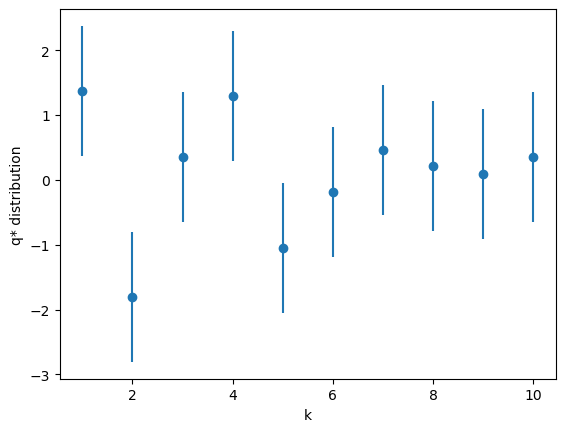

In [4]:
np.random.seed(3110) # set seed to replicate results

# parameters of our "hidden distribution" of prizes
n_levers = 10
mean = 0
std = 1
q_star = np.random.normal(loc = mean, scale = std, size = n_levers) # true value of the means 
plt.errorbar(np.arange(1,len(q_star)+1,1),q_star,yerr = np.tile(1.,len(q_star)), marker = 'o', ls = 'none')
plt.ylabel('q* distribution')
plt.xlabel('k')
plt.show()


The plot above shows the mean rewards of each arm with their variance. There is clearly a preferrable choice (the lever whose q* has an higher average), but the agent has to be able to identify it first. To achieve this, there are several classic RL algorithms.


In [7]:
def regret(x,y,timesteps): 
    regret=(timesteps-np.trapz(y,x))/timesteps
    return regret

## Greedy choice


We need the agent to be able to estimate how good each action (arm choice) can be. For this, the definition of **estimated action value** (Q-value) can be used:

$Q_t(A) = \frac{\sum{R}}{N}$

which corresponds to the mean of the rewards obtained from picking action A for N times.
For the law of large numbers, this quantity converges to the q* of the arm for a large amount of trials. This enables the agent, with sufficient trial and error, to be able to identify correctly which action is the best one to take, identified as **Greedy action**. A way to estimate this quantity for each timestep $t$ (which in context of k-armed bandits corresponds to an episode) is to compute as follows:

$Q_{t+1} = Q_t + \frac{(R_t - Q_t)}{n}$

This expression allows for easy storing of the data we need: no risk of overflow is met with such an update.

We would like the agent to be able to pick the greedy action to get the highest amount of rewards. 
One (naive) approach is an algorithm that tries once all k levers and then sticks to the action found to give the highest reward amount in that trial: **greedy choice algorithm**.

In [9]:
def greedy_algorithm_with_first_push(Q,t):
    # try out all possibilities
    if t < len(Q):
        # action selection
        a_idx = t
    # if he has already ran once all the levers, just pick the best one
    else:
        a_idx = np.argmax(Q)
    # return the chosen lever
    return a_idx
    
def reward_generator(a_idx, q_star, std):
    # for a given choice, the bandit give back a reward extracted from a gaus distrib.
    R = np.random.normal(loc = q_star[a_idx],scale = std) # if size is not specified a scalar is returned
    return R

def update_Q(Q,N,a_idx,R):
    # update the estimate of Q-value according to what found
    Q[a_idx] = Q[a_idx] + (R - Q[a_idx]) / N[a_idx]
    return Q

def optimal_action_metric(actions, best_action):
    num = np.cumsum(actions == best_action) 
    den = np.arange(1,len(actions)+1,1)
    return num/den

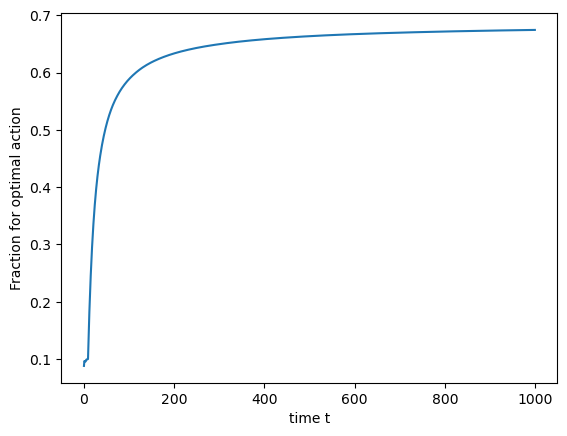

In [13]:
# initialization of N runs
timesteps = 1000 # for how long the agent must play the bandit
metric_saver_fp = np.zeros(timesteps)
n_runs = 2000
all_regrets_fp = []
for i in (range(n_runs)):
    # initialization of algorithm (re-extract the bandits every time)
    q_star = np.random.normal(loc = mean, scale = std, size = n_levers) # true value of the means 
    Q = np.zeros(n_levers)
    N = np.zeros(n_levers)
    
    best_action = np.argmax(q_star)
    actions = np.zeros(timesteps) # save the actions
    # loop
    for t in (range(timesteps)):
        a_idx = greedy_algorithm_with_first_push(Q,t)   # pick an action
        N[a_idx] += 1                                   # increase the counter for that action
        R = reward_generator(a_idx,q_star,std)          # generate the reward
        Q = update_Q(Q,N,a_idx,R)                       # update Q
        actions[t] = a_idx
    
    # convert actions array in cumulative times of best action taken
    metric = optimal_action_metric(actions,best_action)
    metric_saver_fp = metric_saver_fp + (metric - metric_saver_fp)/(i+1)
    run_regret_fp = regret(np.arange(0, timesteps, 1), metric_saver_fp, timesteps)
    all_regrets_fp.append(run_regret_fp) 
    
plt.plot(np.arange(0,timesteps,1),metric_saver_fp)
plt.xlabel('time t')
plt.ylabel('Fraction for optimal action')
plt.show()

    

In [30]:
mean_regret_fp = np.mean(all_regrets_fp)
std_regret_fp = np.std(all_regrets_fp) / np.sqrt(n_runs)  
print(f"regret = {mean_regret_fp:.4f} ± {std_regret_fp:.4f}  ")

regret = 0.3525 ± 0.0006  


The above graph shows how the greedy algorithm performs pushing each lever one time and proceeding from then on with the lever found to be the best one. One could also wonder what would happen if instead the algorithm just picks the highest Q-value lever (without trying all k levers before),  breaking ties randomly picking an arm: **silly greedy algorithm**.

## Silly Greedy

In [20]:
def silly_greedy_algorithm(Q,t):
    # find out the value of the max
    a_idx = np.argmax(Q)
    # check if there are more than one == to max
    n_max = np.where(Q == Q[a_idx])[0]
    # if there is only one, that's our pick!
    if len(n_max == 1):
        return a_idx
    # if there are ties, we should pick one randomly
    else:
        a_idx = int(len(n_max) * np.random.uniform(0,1)) # generates a random index based on the number of tied arms
        return a_idx
    

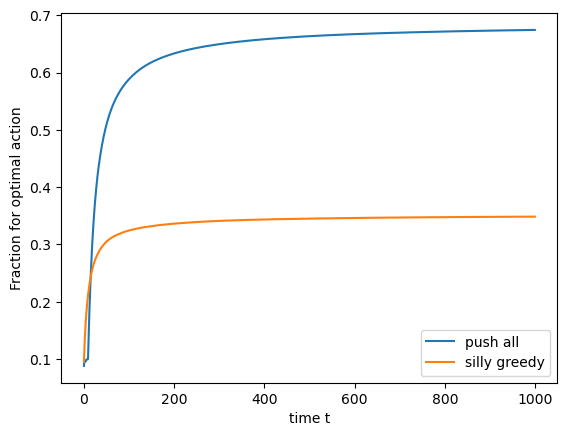

In [29]:
# initialization of Nruns
timesteps = 1000 # for how long the agent must play the bandit
metric_saver_g = np.zeros(timesteps)
n_runs = 2000

all_regrets_g = []

for i in (range(n_runs)):
    # initialization of algorithm (re-extract the bandits every time)
    q_star = np.random.normal(loc = mean, scale = std, size = n_levers) # true value of the means 
    Q = np.zeros(n_levers)
    N = np.zeros(n_levers)
    
    best_action = np.argmax(q_star)
    actions = np.zeros(timesteps) # save the actions
    # loop
    for t in (range(timesteps)):
        a_idx = silly_greedy_algorithm(Q,t)   # pick an action
        N[a_idx] += 1                                   # increase the counter for that action
        R = reward_generator(a_idx,q_star,std)          # generate the reward
        Q = update_Q(Q,N,a_idx,R)                       # update Q
        actions[t] = a_idx
    
    # convert actions array in cumulative times of best action taken
    metric = optimal_action_metric(actions,best_action)
    metric_saver_g = metric_saver_g + (metric - metric_saver_g)/(i+1)
    run_regret_g = regret(np.arange(0, timesteps, 1), metric_saver_g, timesteps)
    all_regrets_g.append(run_regret_g) 

plt.plot(np.arange(0,timesteps,1),metric_saver_fp, label = 'push all')
plt.plot(np.arange(0,timesteps,1),metric_saver_g, label = 'silly greedy')
plt.xlabel('time t')
plt.ylabel('Fraction for optimal action')
plt.legend()
plt.show()


In [31]:
mean_regret_g = np.mean(all_regrets_g)
std_regret_g = np.std(all_regrets_g) / np.sqrt(n_runs)  
print(f"regret = {mean_regret_g:.4f} ± {std_regret_g:.4f}  ")

regret = 0.6565 ± 0.0004  


As we can see, just pressing once each lever allows the agent to have a significantly better performance over time. This is thanks to the **exploration** performed at the start. The agent sacrifices some rewards initially to maximize long term ones. We would like to optimize this **exploration-exploitation** tradeoff even more, by identifying as soon as possible the best lever.

## $\epsilon$-Greedy 

An algorithm that allows us to achieve better performances by exploiting this tradeoff is called **$\epsilon$-greedy**. We define a small quantity $\epsilon$ that allows the agent some exploration: it will take with probability $1-\epsilon$ the greedy action, while with probability $\epsilon$ it will take another action at random. In this way, the agent will mostly pick the actions known to be best at that point in time, but will still explore, allowing itself to find out if another action can be better. 

In [33]:
def epsilon_greedy_algorithm(Q,epsilon):
    # find out the value of the max
    a_idx = np.argmax(Q)
    # extract a number to decide what to do
    dec = np.random.uniform(0,1)
    
    # greedy choice
    if (dec > epsilon):
        # check if there are more than one == to max
        n_max = np.where(Q == Q[a_idx])[0]
        # if there is only one, that's our man!
        if len(n_max == 1):
            return a_idx
        # if there are ties, we should pick one randomly
        else:
            a_idx = int(len(n_max) * np.random.uniform(0,1))
            return a_idx
    # non-greedy choice
    else:
        # possible choices
        pos = np.arange(0,len(Q),1)
        pos = pos[pos != a_idx] # remove the argmax
        a_idx = pos[int(len(pos)*np.random.uniform(0,1))] # pick one random
        return a_idx
        
   

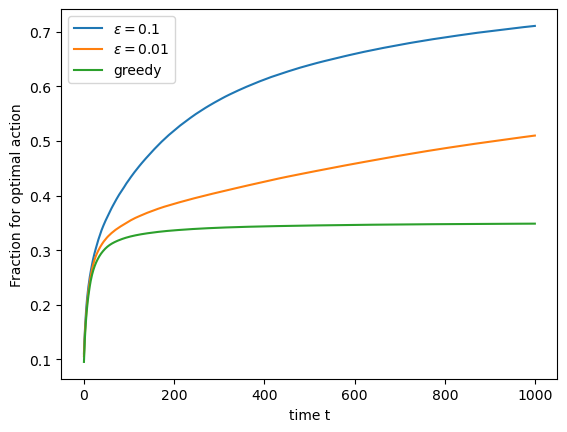

In [56]:
# initialization of Nruns
timesteps = 1000 # for how long the agent must play the bandit
n_runs = 2000
epsilons = [0.1,0.01]
metric_saver_eg_vector=[]
all_regrets_eg_vector = []

for epsilon in epsilons:
    metric_saver_eg = np.zeros(timesteps)
    all_regrets_eg = []
    for i in (range(n_runs)):
        # initialization of algorithm (re-extract the bandits every time)
        q_star = np.random.normal(loc = mean, scale = std, size = n_levers) # true value of the means 
        Q = np.zeros(n_levers)
        N = np.zeros(n_levers)
        
        best_action = np.argmax(q_star)
        actions = np.zeros(timesteps) # save the actions
        # loop
        for t in (range(timesteps)):
            a_idx = epsilon_greedy_algorithm(Q,epsilon)   # pick an action
            N[a_idx] += 1                                   # increase the counter for that action
            R = reward_generator(a_idx,q_star,std)          # generate the reward
            Q = update_Q(Q,N,a_idx,R)                       # update Q
            actions[t] = a_idx
        
        # convert actions array in cumulative times of best action taken
        metric = optimal_action_metric(actions,best_action)
        metric_saver_eg = metric_saver_eg + (metric - metric_saver_eg)/(i+1)
        
        run_regret_eg = regret(np.arange(0, timesteps, 1), metric_saver_eg, timesteps)
        all_regrets_eg.append(run_regret_eg) 
    
    metric_saver_eg_vector.append(metric_saver_eg)
    all_regrets_eg_vector.append(all_regrets_eg)

    plt.plot(np.arange(0,timesteps,1),metric_saver_eg, label = f'$\epsilon = {epsilon}$')
plt.plot(np.arange(0,timesteps,1),metric_saver_g, label = 'greedy')
plt.xlabel('time t')
plt.ylabel('Fraction for optimal action')
plt.legend()
plt.show()

    

# ________________________________________________________________

In [57]:
for i in range(len(epsilons)):
    mean_regret_eg = np.mean(all_regrets_eg_vector[i])
    std_regret_eg = np.std(all_regrets_eg_vector[i]) / np.sqrt(n_runs)  
    print(f"ε={epsilons[i]} -> regret = {mean_regret_eg:.4f} ± {std_regret_eg:.4f}  ")

ε=0.1 -> regret = 0.4031 ± 0.0002  
ε=0.01 -> regret = 0.5587 ± 0.0005  


As $\epsilon$ decreases, the increase of the accuracy with respect to time is slower, but it will approach $1-\epsilon$ at the end. The algorithm will still fail a fraction $\epsilon$ of times at convergence, since it still picks non-greedy actions at random, even if he has discovered which is the best action. To achieve the best performance, the value of $\epsilon$ should be adjusted (reduced) according to runtime $t$.

## Optimistic Initial Values

We can help the algorithm understand which is the best action by providing "optimistic" initial values $Q_0$. This enhances the exploration of the algorithm, since the agent finds itself thinking that some actions will yield even higher rewards than they could ever do. To apply this, **we need some kind of prior knowledge about the problem**. In this context, we know that our $q^*$ distribution is picked out from gaussians extracted with $\mu=0$ and $\sigma=1$. Optimistic initial values then are for example in the $>3$ range.


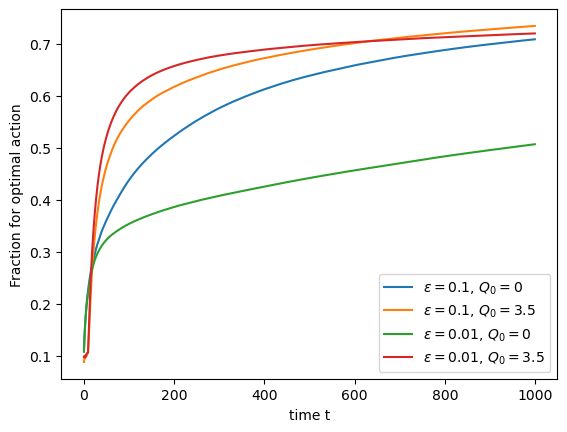

In [58]:
# initialization of Nruns
timesteps = 1000 
n_runs = 2000
epsilons = [0.1,0.01]
Q_zeros = [0,3.5]
metric_saver_egoiv_vector=[]
all_regrets_egoiv_vector = []

for epsilon in epsilons:
    for q_zero in Q_zeros:
        metric_saver_egoiv = np.zeros(timesteps)
        all_regrets_egoiv = []

        for i in (range(n_runs)):
            # initialization of algorithm (re-extract the bandits every time)
            q_star = np.random.normal(loc = mean, scale = std, size = n_levers) # true value of the means 

            if q_zero == 0:
                Q = np.zeros(n_levers)
            else:
                Q = np.ones(n_levers)*q_zero # optimistic initialization
            N = np.zeros(n_levers)
            
            best_action = np.argmax(q_star)
            actions = np.zeros(timesteps) # save the actions
            # loop
            for t in (range(timesteps)):
                a_idx = epsilon_greedy_algorithm(Q,epsilon)   # pick an action
                N[a_idx] += 1                                   # increase the counter for that action
                R = reward_generator(a_idx,q_star,std)          # generate the reward
                Q = update_Q(Q,N,a_idx,R)                       # update Q
                actions[t] = a_idx
            
            # convert actions array in cumulative times of best action taken
            metric = optimal_action_metric(actions,best_action)
            metric_saver_egoiv = metric_saver_egoiv + (metric - metric_saver_egoiv)/(i+1)
            run_regret_egoiv = regret(np.arange(0, timesteps, 1), metric_saver_egoiv, timesteps)
            all_regrets_egoiv.append(run_regret_egoiv) 
            
        metric_saver_egoiv_vector.append(metric_saver_egoiv)
        all_regrets_egoiv_vector.append(all_regrets_egoiv)
        
        plt.plot(np.arange(0,timesteps,1),metric_saver_egoiv, label = f'$\epsilon = {epsilon}$, $Q_0 = {q_zero}$')
#plt.plot(np.arange(0,timesteps,1),metric_saver_g, label = 'greedy')
plt.xlabel('time t')
plt.ylabel('Fraction for optimal action')
plt.legend()
plt.show()

    

In [76]:
for i in range(len(epsilons)):

    mean_regret_egoiv = np.mean(all_regrets_egoiv_vector[i])
    std_regret_egoiv = np.std(all_regrets_egoiv_vector[i]) / np.sqrt(n_runs)  
    print(f"ε={epsilons[i]} -> regret = {mean_regret_egoiv:.4f} ± {std_regret_egoiv:.4f}  ")

ε=0.1 -> regret = 0.3931 ± 0.0004  
ε=0.01 -> regret = 0.3560 ± 0.0006  


From the above plot we see that, in general, using Optimistic Initial Values improves the performance, for a fixed $\epsilon$ value.

## Upper-Confidence bound

We would like to do better than picking the non-greedy action with uniform probability. In general, we would prefer actions that have _chance_ of performing better. Trying them out, we could discover that they lead to higher rewards, or maybe lower. In the latter case, we would have spent one timestep not getting high rewards, but we would have gained information. 
This can be achieved considering a function that accounts for the uncertainty associated with each lever (how confident we are for each single action), instead the expected reward $Q_t$. The new action choice becomes:

$$ A(t) = argmax(Q_i(t)+ c\sqrt{ln(t)/N_i(t)} ) $$

UCB bascally adds an exploration term based on the uncertainty of each arm, where:
- $N$ is an array containing how many times each specific arm has been pulled so-far.
- $c$ is a hyperparameter (the exploration degree) that controls how much we value uncertainty. 
  
If an arm hasn't been pulled much, $N_i$ is small, making the exploration bonus very large. This eventually forces the algorithm to pick that arm, even if its current $Q_i$ is low, just to "check" if it has improved.


In [63]:
def UCB_algorithm(Q,c,N,t):
    a_idx = np.argmax(Q + c*np.sqrt(np.log(t)/N)) # argmax of this is the desired index
    # check for ties and break them randomly
    n_max = np.where(Q == Q[a_idx])[0]
    # if there is only one, that's our man!
    if len(n_max == 1):
        return a_idx
    # if there are ties, we should pick one randomly
    else:
        a_idx = int(len(n_max) * np.random.uniform(0,1))
        return a_idx

/tmp/ipykernel_733/3136958740.py:2: RuntimeWarning: divide by zero encountered in log          | 0/2000 [00:00<?, ?it/s]
  a_idx = np.argmax(Q + c*np.sqrt(np.log(t)/N)) # argmax of this is the desired index
/tmp/ipykernel_733/3136958740.py:2: RuntimeWarning: invalid value encountered in sqrt
  a_idx = np.argmax(Q + c*np.sqrt(np.log(t)/N)) # argmax of this is the desired index
100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:14<00:00, 138.80it/s]


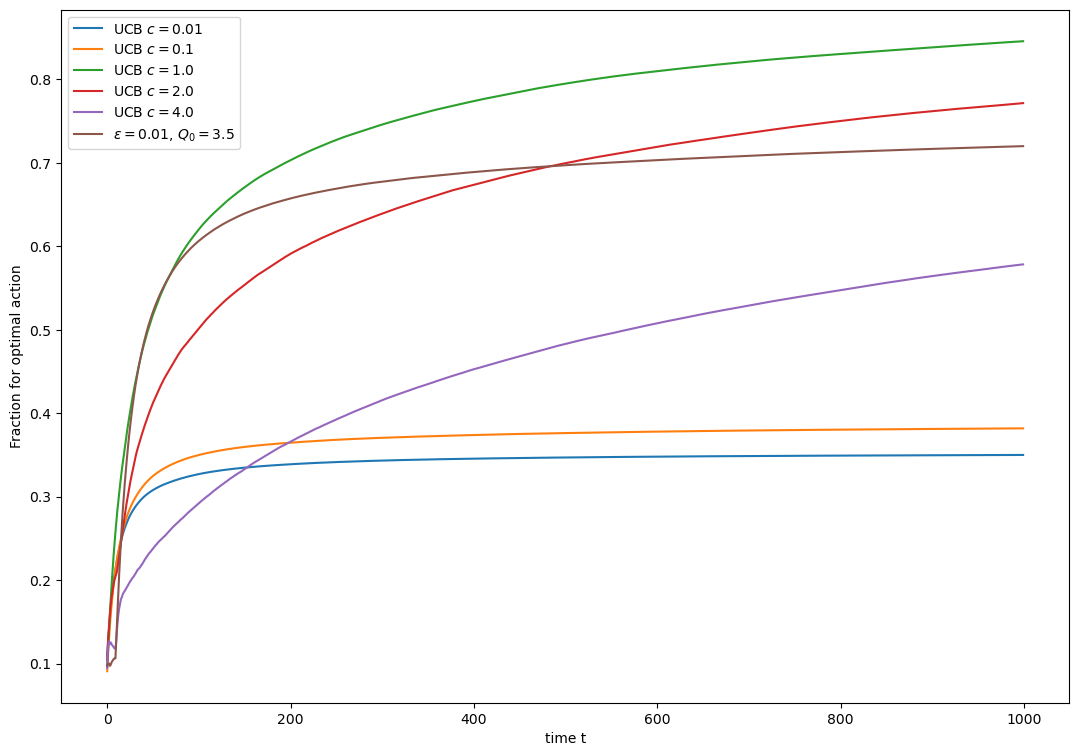

In [74]:
# initialization of Nruns
timesteps = 1000 # for how long the agent must play the bandit
n_runs = 2000
c_s = [0.01,0.1,1.,2.,4.]
metric_saver_UCB_vector=[]
all_regrets_UCB_vector = []
plt.figure(figsize=(13,9))

for c in c_s:
    metric_saver_UCB = np.zeros(timesteps)
    all_regrets_UCB = []
    
    for i in tqdm(range(n_runs)):
        # initialization of algorithm (re-extract the bandits every time)
        q_star = np.random.normal(loc = mean, scale = std, size = n_levers) # true value of the means 

        Q = np.zeros(n_levers)
        N = np.ones(n_levers)   # avoid division by 0
            
        best_action = np.argmax(q_star)
        actions = np.zeros(timesteps) # save the actions
        
        for t in (range(timesteps)):
            a_idx = UCB_algorithm(Q,c,N,t)                  # picks the action
            N[a_idx] += 1                                   # increase the counter for that action
            R = reward_generator(a_idx,q_star,std)          # generate the reward
            Q = update_Q(Q,N,a_idx,R)                       # update Q
            actions[t] = a_idx
            
        # convert actions array in cumulative times of best action taken
        metric = optimal_action_metric(actions,best_action)
        metric_saver_UCB = metric_saver_UCB + (metric - metric_saver_UCB)/(i+1)
        run_regret_UCB = regret(np.arange(0, timesteps, 1), metric_saver_UCB, timesteps)
        all_regrets_UCB.append(run_regret_UCB) 
        
    metric_saver_UCB_vector.append(metric_saver_UCB)
    all_regrets_UCB_vector.append(all_regrets_UCB)
    plt.plot(np.arange(0,timesteps,1),metric_saver_UCB, label = f'UCB $c = {c}$')
        
plt.plot(np.arange(0,timesteps,1),metric_saver_egoiv, label = f'$\epsilon = {epsilon}$, $Q_0 = {q_zero}$')
#plt.plot(np.arange(0,timesteps,1),metric_saver_g, label = 'greedy')
plt.xlabel('time t')
plt.ylabel('Fraction for optimal action')
plt.legend(loc='best')
plt.show()

    

In [78]:
for i in range(len(c_s)):
    mean_regret_UCB = np.mean(all_regrets_UCB_vector[i])
    std_regret_UCB = np.std(all_regrets_UCB_vector[i]) / np.sqrt(n_runs)  
    print(f"c={c_s[i]} -> regret = {mean_regret_UCB:.4f} ± {std_regret_UCB:.4f}  ")

c=0.01 -> regret = 0.6623 ± 0.0006  
c=0.1 -> regret = 0.6222 ± 0.0004  
c=1.0 -> regret = 0.2427 ± 0.0003  
c=2.0 -> regret = 0.3434 ± 0.0002  
c=4.0 -> regret = 0.5502 ± 0.0002  


# Bayesian K-Armed Bandit 

Now **the agent constructs a posterior probability distribution for the reward of each arm**. To do this we use **Thomson sampling**, which consists in: 
- Sampling: at every step, the agent draws one random sample from each arm's posterior distribution.
- Action: it picks the arm that produced the highest sample among these, and a reward is obtained.
- Update: after observing the reward, it uses Bayes' Theorem to update the posterior of each arm.

Here we initialize the agent's belief for each arm with a **highly uninformative (flat) gaussian prior**, with $μ_0=0$ and $σ_0=100$. Since the likelihood is also gaussian,$N(\mu,\sigma_{like}^2=1)$, we have that the prior and the posterior are conjugate distributions, and in particular **the posterior is a gaussian** $N(\mu_{post},\sigma_{post}^2)$ with:
$$\mu_{post} = \sigma^2_{post} \left( \frac{\mu_{prior}}{\sigma^2_{prior}} + \frac{R}{\sigma^2_{like}} \right)$$

$$\frac{1}{\sigma^2_{post}} = \frac{1}{\sigma^2_{prior}} + \frac{1}{\sigma^2_{like}}$$.

So in this case we have an **analytical expression for the posterior and we can draw samples from it** to apply Thomson sampling. At each timestep, the posterior becomes the new prior to update.  


In [81]:
def optimal_action_metric(actions, best_action):
    num = np.cumsum(actions == best_action) 
    den = np.arange(1,len(actions)+1,1)
    return num/den

def thompson_sampling(mu_prior, std_prior):
    theta = np.random.normal(mu_prior, std_prior)
    return np.argmax(theta)

def reward_generator(a, q_star, env_std):
    return np.random.normal(q_star[a], env_std)

def update_posterior(mu_prior, std_prior, a, reward, std_like):
    var_prior = std_prior[a]**2
    var_like = std_like**2

    # posterior
    var_post = 1./(1./var_prior + 1./var_like)
    mu_post = var_post*(mu_prior[a]/var_prior+reward/var_like)

    # update
    mu_prior[a] = mu_post
    std_prior[a] = np.sqrt(var_post)

    return mu_prior, std_prior



In [89]:
timesteps = 1000
n_runs = 2000

real_mean = 0.0
real_std = 1.0

std_like = 1.0

metric_saver_b = np.zeros(timesteps)
all_regrets_b = []

 

for i in tqdm(range(n_runs)):

    # true arms' values 
    q_star = np.random.normal(real_mean, real_std, size=n_levers)
    best_action = np.argmax(q_star)

    # prior initialization
    Q = np.zeros(n_levers)
    std = np.ones(n_levers) * 100.0

    actions = np.zeros(timesteps)
    for t in range(timesteps):
        a_idx = thompson_sampling(Q, std)
        R = reward_generator(a_idx, q_star, std_like)
        Q, std = update_posterior(Q, std, a_idx, R, std_like)
        actions[t] = a_idx

    metric = optimal_action_metric(actions, best_action)
    metric_saver_b += (metric-metric_saver_b)/(i+1)
    run_regret_b = regret(np.arange(0, timesteps, 1), metric_saver_b, timesteps)
    all_regrets_b.append(run_regret_b)


100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:15<00:00, 129.36it/s]


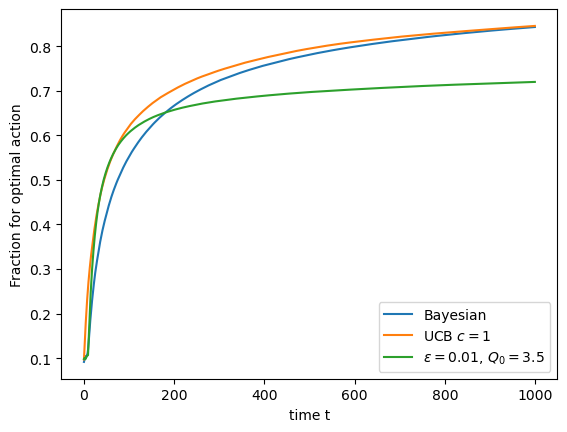

In [90]:
plt.plot(np.arange(0,timesteps,1),metric_saver_b,label='Bayesian')
plt.xlabel('time t')
plt.ylabel('Fraction for optimal action')
plt.plot(np.arange(0,timesteps,1),metric_saver_UCB_vector[2], label = f'UCB $c = {1}$')
plt.plot(np.arange(0,timesteps,1),metric_saver_egoiv, label = f'$\epsilon = {epsilon}$, $Q_0 = {q_zero}$')
plt.legend()
plt.show()


In [91]:
mean_regret_b = np.mean(all_regrets_b)
std_regret_b = np.std(all_regrets_b) / np.sqrt(n_runs)  
print(f"regret = {mean_regret_b:.4f} ± {std_regret_b:.4f}  ")

regret = 0.2731 ± 0.0002  


# Regrets

Metric describing which algorithm has faster convergence and higher accuracy: calculated as 1 - normalized AUC of the fraction of optimal choices (average over the multiple runs).

In [116]:
print("_" * 50)
print(f'\nGreedy:  {mean_regret_fp:.4f} ± {std_regret_fp:.4f}')

print("_" * 50)

print(f'\nSilly: {mean_regret_g:.4f} ± {std_regret_g:.4f}')
print("_" * 50)

print('\nε-greedy:')
for i in range(len(epsilons)):
    print(f'{epsilons[i]}->{np.mean(all_regrets_eg_vector[i]):.4f} ± {np.std(all_regrets_eg_vector[i]) / np.sqrt(n_runs)  :.4f}')
print("_" * 50)

print('\nOptimistic Intial Values:')
for i in range(len(epsilons)):
    print(f'{epsilons[i]}->{np.mean(all_regrets_egoiv_vector[i]):.4f} ± {np.std(all_regrets_egoiv_vector[i]) / np.sqrt(n_runs)  :.4f}')
print("_" * 50)

print('\nUCB:')
for i in range(len(c_s)):
    print(f'{c_s[i]}->{np.mean(all_regrets_UCB_vector[i]):.4f} ± {np.std(all_regrets_UCB_vector[i]) / np.sqrt(n_runs)  :.4f}') 
print("_" * 50)

print(f'\nBayesian: {mean_regret_b:.4f} ± {std_regret_b:.4f} \n')
print("_" * 50)


__________________________________________________

Greedy:  0.3525 ± 0.0006
__________________________________________________

Silly: 0.6607 ± 0.0002
__________________________________________________

ε-greedy:
0.1->0.4031 ± 0.0002
0.01->0.5587 ± 0.0005
__________________________________________________

Optimistic Intial Values:
0.1->0.3931 ± 0.0004
0.01->0.3560 ± 0.0006
__________________________________________________

UCB:
0.01->0.6623 ± 0.0006
0.1->0.6222 ± 0.0004
1.0->0.2427 ± 0.0003
2.0->0.3434 ± 0.0002
4.0->0.5502 ± 0.0002
__________________________________________________

Bayesian: 0.2731 ± 0.0002 

__________________________________________________


For this simple case, we observe that the Bayesian approach (assuming an almost flat prior) actually sligthly underperfoms the best UCB (c=1) algorithm, which also defines a quantitative notion of the uncertainty of each arm. However, **Bayesian approach has the important advantage that it does not require to "manually" fine-tune the algorithm's hyper-paramters** to get them most efficient performance, while still obtaining a very low regret (in a real case scenario in fact one of course cannot actually evaluate the regret, we can just play the game again with a different algorithm and check the average reward).  

# Bayesian framework: general case


We now consider a more general case, in which we do not have an analytical posterior. We consider two possible approaches to aprroximate and sample from the posterior distribution at each update: MCMC-based method and Variational inference. 

### Bayesian Multi-Armed Bandit (MAB) agent with Markov Chain Monte Carlo (MCMC)

The agent maintains a probability distribution (belief) for the reward of each arm. Again, we want to use Thomson sampling:
- Sampling: in every step, the agent draws one random sample from each arm's belief distribution.
- Action: it picks the arm that produced the highest sample.
- Update: after observing the reward, it uses Bayes' Theorem to update its belief (posterior of each arm). 

Here, each arm's reward follows a **Gaussian distribution with a certain mean and variance, both uknown to the agent**. We use a **T-student prior** for each arm, in order to allow the possibility of large tails for the rewards distributions. 
Therefore, we do not have an analytical expression for the posterior distribution of the parameters of each arm: we **use MCMC to numerically approximate the posterior and sample from it at convergence at each update**. We then use again Thomson sampling, picking a single sample from the posterior of the means, and choosing the arm with the highest mean in this sample as action. In this case the means' estimate also depend on the posterior estimate of the variances.   

In [1]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import warnings

class GeneralMCMCBandit:
    def __init__(self, n_arms, n_samples=100):
        self.n_arms = n_arms
        self.n_samples = n_samples
        
        self.actions = [] # indices of arms pulled
        self.rewards = [] # history of rewards observed
        
        # Initial belief: samples drawn from the prior... We start with a matrix of (n_samples, n_arms)
       
        self.posterior_mu = np.random.standard_t(df=3, size=(n_samples, n_arms))
      
        self.posterior_sigma = np.abs(np.random.normal(loc=1.0, scale=0.5, size=(n_samples, n_arms)))

    def select_arm(self):
        """
        Thompson Sampling:
        - Pick a random sample (row) from our posterior belief.
        - Pick the arm with the highest mean in that sample."""
     
        random_idx = np.random.randint(0, self.posterior_mu.shape[0])
        # the sample row contains one potential reality for all arms
        sample_means = self.posterior_mu[random_idx] 
        return np.argmax(sample_means)

    def update(self, action, reward):
        self.actions.append(action)
        self.rewards.append(reward)
        
        # use numpy for PyMC
        obs_actions = np.array(self.actions) 
        obs_rewards = np.array(self.rewards)
        
        # GENERAL FRAMEWORK (MCMC)
        # in pm.sample i have n samples=100 and tune=1000 (burn in), 
        # I update the chain (posterior) 1100 times (so i'll have 1100 different mu and thus mu_observed)...
        # we keep only the last 100 as sampled samples, among which we then use thomsomn sampling and keep a single one, to choose the best arm
        
        with pm.Model() as model: # every variable defined inside this block belongs to a specific probabilistic model
            
            # PRIORS: # These define rules and not variables assignment 
            
            # Prior for the spread (noise) of the arms; use half-normal since we assume it's positive
            sigma = pm.HalfNormal('sigma', sigma=1.0, shape=self.n_arms) 
            
            # Prior for the Mean reward of the arms: T-Student (allows for outliers/heavy tails)
            # This is NON-conjugate with a Gaussian likelihood.
            mu = pm.StudentT('mu', nu=3, mu=0, sigma=2.0, shape=self.n_arms)
            
            # LIKELIHOOD CONSTRUCTION
            # At each update we compute the joint likelihood of the whole history of rewards 
            # (instead of updating at each step the prior with the previous posterior, that we do not have explicitely)
            
            # We need to map the "actions" history to their "mu" and "sigma" parameters...
            # mu[obs_actions] selects the mu corresponding to the arm pulled at that step.
          
            mu_selected = mu[obs_actions] # vector with succesion of the estimated mu for the pulled arm at the different timesteps
            sigma_selected = sigma[obs_actions]
            

            y = pm.Normal('y', mu= mu_selected, sigma= sigma_selected, observed=obs_rewards) # 'observed =' tells the model this is the likeilihood of the observed data!
            
            # INFERENCE
            # Run NUTS sampler based on previous prior and likelihood: it runs (multiple parallel) chians using Hamiltonian Monte-Carlo 
            # tune=500: warmup steps (burn in)
            
            # draws=self.n_samples: how many posterior samples to keep 
            idata = pm.sample(draws=self.n_samples, tune=1000, chains=1, progressbar=False)
            
            # extract the posterior samples for 'mu' and 'sigma'
            extracted = az.extract(idata, var_names=['mu','sigma'])
            
            self.posterior_mu = extracted['mu'].values.T
            self.posterior_sigma=  extracted['sigma'].values.T


Here we simulate a single run (game) with 5 arms, played for 500 iterations. At each iteration we draw 100 samples from the MCMC when at convergence (burn in of 1000) and then randomly pick one.

Only 100 samples in chain.


True Means: [1.0, -2.0, 4.0, 3.0, -3.0]
True Sigmas: [0.5, 1, 2.0, 1.5, 2]
----------------------------------------
Step 1: Pulled Arm 4, Reward -6.05


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sigma, mu]
Sampling 1 chain for 1_000 tune and 100 draw iterations (1_000 + 100 draws total) took 4 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 100 samples in chain.


Step 2: Pulled Arm 2, Reward 1.80


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sigma, mu]
Sampling 1 chain for 1_000 tune and 100 draw iterations (1_000 + 100 draws total) took 4 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 100 samples in chain.


...

Step 499: Pulled Arm 2, Reward 5.31


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sigma, mu]
Sampling 1 chain for 1_000 tune and 100 draw iterations (1_000 + 100 draws total) took 4 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 100 samples in chain.


Step 500: Pulled Arm 2, Reward 2.13


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [sigma, mu]
Sampling 1 chain for 1_000 tune and 100 draw iterations (1_000 + 100 draws total) took 4 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


----------------------------------------
Final Estimated Means and Standard Deviations (Posterior):
Arm 0: Mean 0.49 (True 1.0), Std 0.598 (True 0.5)
Arm 1: Mean -1.84 (True -2.0), Std 0.906 (True 1)
Arm 2: Mean 3.80 (True 4.0), Std 1.934 (True 2.0)
Arm 3: Mean 2.77 (True 3.0), Std 1.250 (True 1.5)
Arm 4: Mean -5.18 (True -3.0), Std 1.084 (True 2)
Regret: 0.101


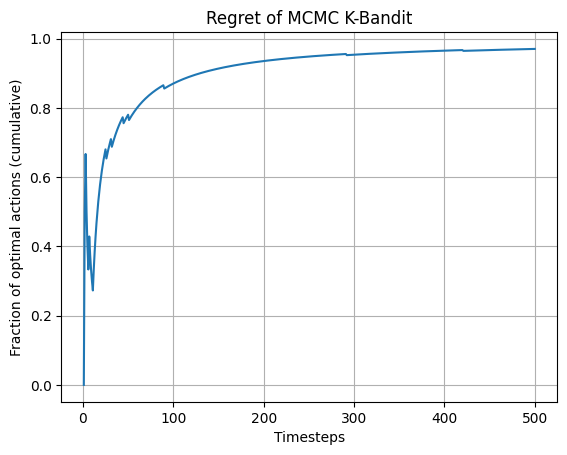

/home/jonny/.local/lib/python3.8/site-packages/arviz/utils.py:184: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


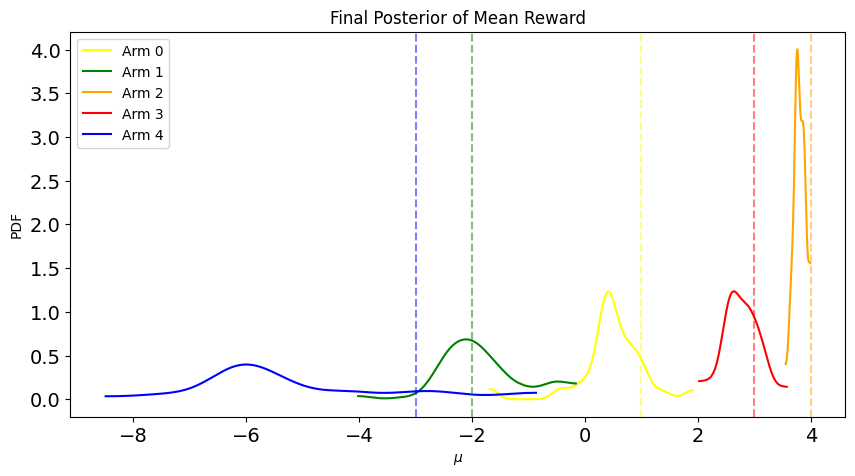

In [4]:
# SINGLE RUN (game) for N_steps=500

def run_gaussian_simulation():
    
    # 5 arms with different Means and Sigmas
    # Arm 2 is the best (mean=4)
    
    TRUE_MEANS = [1.0,-2.0,4.0,3.0,-3.0] 
    TRUE_SIGMAS = [0.5,1,2.0,1.5,2] # the best arm is also noisy!
    N_ARMS = len(TRUE_MEANS)
    N_STEPS = 500
    
    agent = GeneralMCMCBandit(N_ARMS, n_samples=100)
    
    optimal_action_history = []
    best_possible_mean = np.max(TRUE_MEANS)
    
    print(f"True Means: {TRUE_MEANS}")
    print(f"True Sigmas: {TRUE_SIGMAS}")
    print("-" *40)
    
    for t in range(N_STEPS):
        
        # 1. agent picks arm
        arm = agent.select_arm()
        
        # 2. generate Gaussian reward
        reward = np.random.normal(loc=TRUE_MEANS[arm], scale=TRUE_SIGMAS[arm])
        
        # 3. agent updates posterior 
        print(f"Step {t+1}: Pulled Arm {arm}, Reward {reward:.2f}")
        agent.update(arm, reward) 
        
        # 4. calculate Regret (based on the arm choice, not on the noisy reward)
        # regret is:  1-the normalized area under the curve of the fraction of optimal choices vs timesteps  
        
        is_optimal= 1 if TRUE_MEANS[arm]==best_possible_mean else 0
        optimal_action_history.append(is_optimal)

    optimal_fraction_curve= np.cumsum(optimal_action_history)/np.arange(1,N_STEPS+1)
    regret= (N_STEPS - np.trapz(optimal_fraction_curve,np.arange(1,N_STEPS+1)))/N_STEPS 

    print("-" * 40)
    print("Final Estimated Means and Standard Deviations (Posterior):")
    estimated_means = np.mean(agent.posterior_mu, axis=0)
    estimated_stds = np.mean(agent.posterior_sigma, axis=0)
    for k in range(N_ARMS):
        print(f"Arm {k}: Mean {estimated_means[k]:.2f} (True {TRUE_MEANS[k]}), Std {estimated_stds[k]:.3f} (True {TRUE_SIGMAS[k]})")
    print(f"Regret: {regret:.3f}")
    
    # Visualization
    
    # Fraction of optimal choices
    plt.plot(np.arange(1,N_STEPS+1),optimal_fraction_curve,label=f'Regret={regret:.2f}')
    plt.xlabel("Timesteps")
    plt.ylabel("Fraction of optimal actions (cumulative)")
    plt.title("Regret of MCMC K-Bandit")
    plt.grid()
    plt.show()

    # Final Posterior Distributions for mu 
    colors=['yellow','green','orange','red','blue']
    plt.figure(figsize=(10,5))
    for k in range(N_ARMS):
        az.plot_dist(agent.posterior_mu[:, k], label=f'Arm {k}',color=colors[k])
        
    plt.axvline(TRUE_MEANS[0], color='yellow', linestyle='--', alpha=0.5)
    plt.axvline(TRUE_MEANS[1], color='green', linestyle='--', alpha=0.5)
    plt.axvline(TRUE_MEANS[2], color='orange', linestyle='--', alpha=0.5)
    plt.axvline(TRUE_MEANS[3], color='red', linestyle='--', alpha=0.5)
    plt.axvline(TRUE_MEANS[4], color='blue', linestyle='--', alpha=0.5)
    plt.title("Final Posterior of Mean Reward")
    plt.legend(loc='best')
    plt.xlabel(r'$\mu$')
    plt.ylabel('PDF')
    plt.show()

if __name__ == "__main__":
    run_gaussian_simulation()

We then run 100 different simulations of the game on a CloudVeneto GPU (refer to the attached `bayesian_k_bandit_mcmc_script.py` for the implementation), each with 100 timesteps; we obtain the following results.

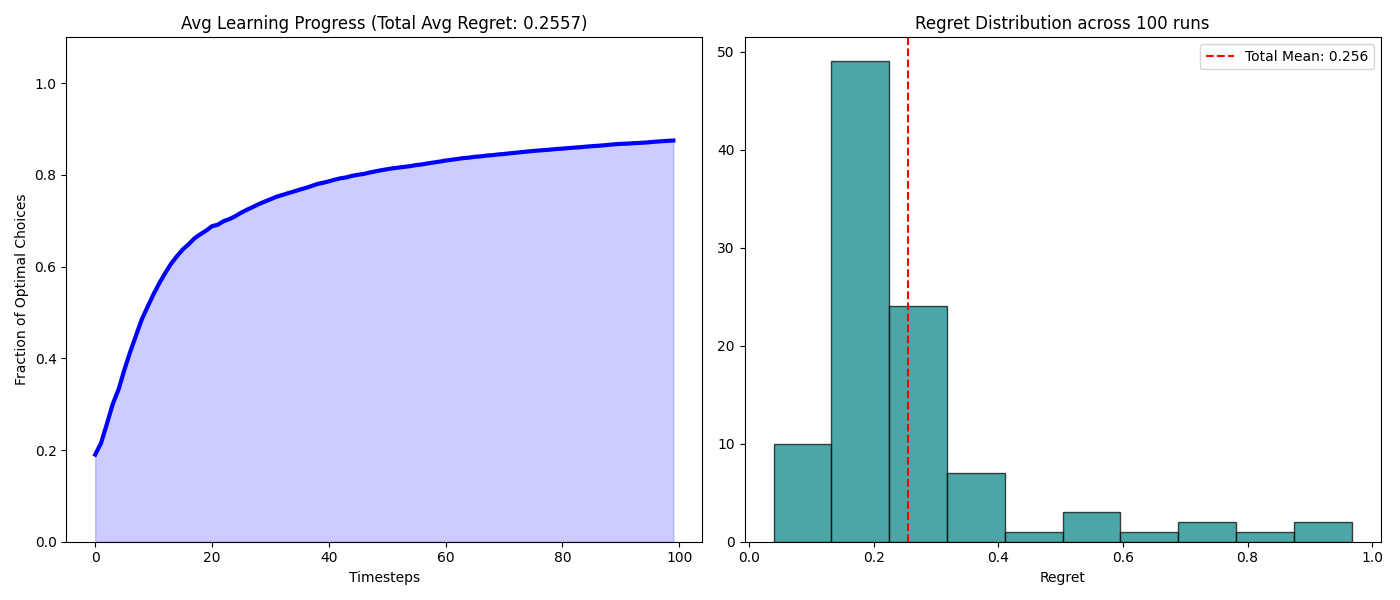

In [67]:
from IPython.display import Image
Image(filename='progress_plot_run_100.png')

In [74]:
import pandas as pd

df = pd.read_csv('all_mcmc_run_regrets.csv')
runs_regrets = df.values.flatten()
mean_regret= np.mean(runs_regrets)
print(f'Mean regret with MCMC-based method {mean_regret:.3f} +- {np.std(runs_regrets)/len(runs_regrets)**0.5:.3f}')

Mean regret with MCMC-based method 0.256 +- 0.017


# Variational Inference with Thompson Sampling and ELBO

- The goal of this method is to **infer the posterior p(θ∣D)** by approximating it with a simpler distribution q(θ).
- q(θ) is chosen by minimizing the KL-Divergence, KL(q∥p). To do so we actually maximize the **ELBO** (Evidence Lower BOund).

The reward is modelled as a mixture of K-gaussian (K=2 in our case)

$$R(y)=\sum_{k=1}^K \pi_{a,k}\hspace{0.1cm} \mathcal{N}(\mu_{a,k},\sigma^2_{a,k})$$

with parameters sampled as such:

$\tilde{\pi}_a \sim Dir(\tilde{\gamma}_a)$

$\tilde{\sigma}^2_{a,k} \sim \Gamma^{-1}(\tilde{\alpha}_{a,k}, \tilde{\beta}_{a,k})$

$\tilde{\pi}_a \sim \mathcal{N}(\tilde{u}_{a,k}, \tilde{\sigma}^2_{a,k} \tilde{V}_{a,k})$

Thompson sampling is than applied to choose the best action and the posteriors updated.

As for the cae before we tried running the algorithm 100 times and averaged the results.

In [6]:
def calculate_elbo(D, gamma, alpha, beta, u, V,
                   gamma_0, alpha_0, beta_0, u_0, V_0,
                   n_levers, Ka, r_ak_list):

    elbo = 0.0

    for lev in range(n_levers):

        # Cmpute KL 
        sum_gamma   = np.sum(gamma[lev])
        sum_gamma_0 = np.sum(gamma_0)

        kl_dir = (loggamma(sum_gamma) - np.sum(loggamma(gamma[lev]))
                 - loggamma(sum_gamma_0) + np.sum(loggamma(gamma_0))
                 + np.sum((gamma[lev] - gamma_0) *
                          (digamma(gamma[lev]) - digamma(sum_gamma))))
        elbo -= kl_dir

        for k in range(Ka):
            kl_ng = (0.5 * np.log(V[lev][k] / V_0[k])
                    - 0.5
                    + 0.5 * (V_0[k] / V[lev][k] + (u[lev][k] - u_0[k])**2 / V[lev][k])
                    + alpha_0[k] * np.log(beta[lev][k] / beta_0[k])
                    - loggamma(alpha[lev][k]) + loggamma(alpha_0[k])
                    + (alpha[lev][k] - alpha_0[k]) * digamma(alpha[lev][k])
                    - (beta[lev][k] - beta_0[k]) * alpha[lev][k] / beta[lev][k])
            elbo -= kl_ng

        #compute entropy
        arm_data = [(i, r) for i, (arm, r) in enumerate(D) if arm == lev]
        if not arm_data:
            continue

        indices, rewards_a = zip(*arm_data)
        rewards_a = np.array(rewards_a)
        r_ak = r_ak_list[lev]

        for i in range(len(rewards_a)):
            for k in range(Ka):
                if r_ak[i, k] > 1e-12:
                    elbo += r_ak[i, k] * (
                        -0.5 * np.log(2 * np.pi)
                        + 0.5 * (digamma(alpha[lev][k]) - np.log(beta[lev][k]))
                        - 0.5 * alpha[lev][k] / beta[lev][k] * (rewards_a[i] - u[lev][k])**2
                        + digamma(gamma[lev][k]) - digamma(sum_gamma)
                    )
                    elbo -= r_ak[i, k] * np.log(r_ak[i, k])

    return elbo

In [7]:
def vts(n_levers, Ka, timesteps, iterations, q_star, q_star_sigma):  # ← aggiunto q_star, q_star_sigma
    gamma_0 = np.ones(Ka)*0.1
    u_0 = np.zeros(Ka)*0.5
    V_0 = np.ones(Ka) * 100.0
    alpha_0 = 0.5 * np.ones(Ka)
    beta_0 = 2.0 * np.ones(Ka)

    gamma = [gamma_0.copy() for _ in range(n_levers)]
    alpha = [alpha_0.copy() for _ in range(n_levers)]
    beta  = [beta_0.copy()  for _ in range(n_levers)]
    u     = [u_0.copy()     for _ in range(n_levers)]
    V     = [V_0.copy()     for _ in range(n_levers)]

    D = []
    Q = np.zeros(timesteps, dtype=int)
    R = np.zeros(timesteps)

    for t in tqdm(range(timesteps)):
        mu_a = np.zeros(n_levers)

        for lev in range(n_levers):
            pi = rnd.dirichlet(gamma[lev])
            component_rewards = np.zeros(Ka)
            for k in range(Ka):
                var_k = 1. / rnd.gamma(alpha[lev][k], scale=beta[lev][k])
                mu_k = rnd.normal(loc=u[lev][k], scale=np.sqrt(var_k * V[lev][k]))
                component_rewards[k] = mu_k
            mu_a[lev] = np.sum(pi * component_rewards)

        a_idx = np.argmax(mu_a)
        Q[t] = a_idx
        y_t = np.random.normal(q_star[a_idx], q_star_sigma[a_idx])  # ← usa q_star_sigma
        R[t] = y_t
        D.append((a_idx, y_t))

        elbo_old = -np.inf
        for iter in range(iterations):
            r_ak_list = [None] * n_levers
            for lev in range(n_levers):
                arm_data = [(i, r) for i, (arm, r) in enumerate(D) if arm == lev]
                if not arm_data:
                    continue
                indices, rewards_a = zip(*arm_data)
                rewards_a = np.array(rewards_a)
                n_samples = len(rewards_a)

                r_ak = np.zeros((n_samples, Ka))
                for i in range(n_samples):
                    log_rho = np.zeros(Ka)
                    for k in range(Ka):
                        log_rho[k] = -0.5 * (np.log(beta[lev][k]) - digamma(alpha[lev][k])) \
                                    - 0.5 * alpha[lev][k]/beta[lev][k] * ((rewards_a[i] - u[lev][k])**2) \
                                    + digamma(gamma[lev][k]) - digamma(np.sum(gamma[lev]))
                    log_rho = log_rho - np.max(log_rho)
                    rho = np.exp(log_rho)
                    r_ak[i] = rho / np.sum(rho)
                r_ak_list[lev] = r_ak

                for k in range(Ka):
                    R_ak = np.sum(r_ak[:, k])
                    gamma[lev][k] = gamma_0[k] + R_ak
                    V[lev][k] = 1.0 / (1.0/V_0[k] + R_ak)
                    if R_ak > 0:
                        u[lev][k] = V[lev][k] * (u_0[k]/V_0[k] + np.sum(r_ak[:, k] * rewards_a))
                    alpha[lev][k] = alpha_0[k] + 0.5 * R_ak
                    beta_sum = 0
                    if R_ak > 0:
                        beta_sum = 0.5 * np.sum(r_ak[:, k] * (rewards_a - u[lev][k])**2)
                    beta[lev][k] = beta_0[k] + beta_sum + 0.5 * (u[lev][k] - u_0[k])**2 / V_0[k]

            elbo_new = calculate_elbo(D, gamma, alpha, beta, u, V, gamma_0, alpha_0, beta_0, u_0, V_0, n_levers, Ka, r_ak_list)
            if abs(elbo_new - elbo_old) < epsilon:
                break
            elbo_old = elbo_new

    return Q, R

run n.0


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:39<00:00, 25.59it/s]


run n.1


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:39<00:00, 25.21it/s]


run n.2


...

run n.98


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:21<00:00, 46.11it/s]


run n.99


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.95it/s]


Run 100/100 finished. Total Avg Regret: 0.1190


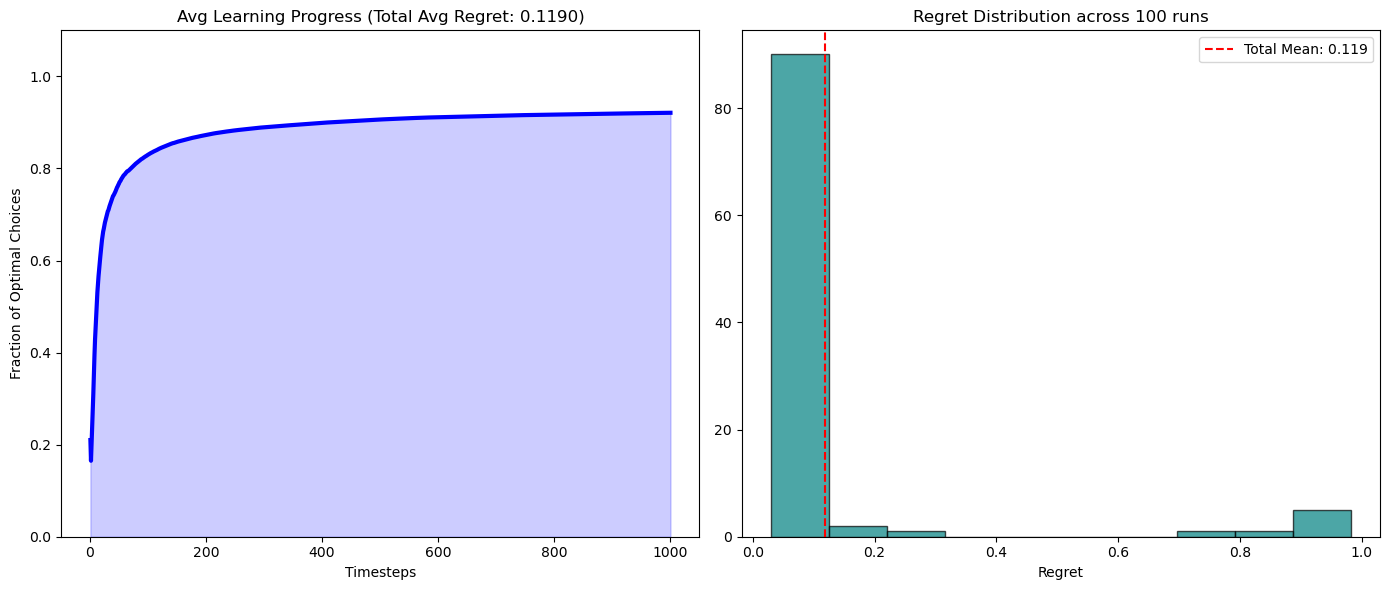

Mean Regret: 0.1190


In [9]:
# Configuration
n_levers   = 5
n_runs     = 100
timesteps  = 1000
Ka         = 2
iterations = 500
epsilon    = 0.001

output_folder = f"VTS_results_{n_runs}_runs"
if not os.path.exists(output_folder):
    os.makedirs(output_folder, exist_ok=True)

metric_saver_elbo   = np.zeros(timesteps)
all_run_regrets     = []
all_fraction_curves = []

timesteps_arr = np.arange(1, timesteps + 1)

for i in range(n_runs):
    print(f'run n.{i}')

    q_star       = np.random.normal(0, 5, size=n_levers)
    q_star_sigma = np.random.uniform(0.5, 2.5, size=n_levers)
    best_action  = np.argmax(q_star)

    actions, rewards = vts(n_levrs, Ka, timesteps, iterations, q_star, q_star_sigma)

    optimal_fraction_curve = optimal_action_metric(actions, best_action)
    metric_saver_elbo += (optimal_fraction_curve - metric_saver_elbo) / (i + 1)

    regret_val = regret(timesteps_arr, optimal_fraction_curve, timesteps)
    all_run_regrets.append(regret_val)
    all_fraction_curves.append(optimal_fraction_curve)

    current_total_avg          = np.mean(all_run_regrets)
    current_avg_fraction_curve = np.mean(all_fraction_curves, axis=0)

    if (i + 1) == n_runs:
        print(f"Run {i+1}/{n_runs} finished. Total Avg Regret: {current_total_avg:.4f}")

        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.plot(timesteps_arr, current_avg_fraction_curve, lw=3, color='blue')
        plt.fill_between(timesteps_arr, current_avg_fraction_curve, alpha=0.2, color='blue')
        plt.title(f"Avg Learning Progress (Total Avg Regret: {current_total_avg:.4f})")
        plt.xlabel("Timesteps")
        plt.ylabel("Fraction of Optimal Choices")
        plt.ylim(0, 1.1)

        plt.subplot(1, 2, 2)
        plt.hist(all_run_regrets, color='teal', edgecolor='black', alpha=0.7)
        plt.axvline(current_total_avg, color='red', linestyle='--', label=f"Total Mean: {current_total_avg:.3f}")
        plt.title(f"Regret Distribution across {i+1} runs")
        plt.xlabel("Regret")
        plt.legend()

        plt.tight_layout()
        plt.savefig(f"{output_folder}/progress_plot_run_{i+1}.png")
        plt.show()
        plt.close()

mean_regret         = np.mean(all_run_regrets)
mean_fraction_curve = np.mean(all_fraction_curves, axis=0)
print(f"Mean Regret: {mean_regret:.4f} +- {np.std(all_run_regrets)/len(all_run_regrets)**0.5:.3f}")

## Classical RL algorithms for the non-analyitical general case

In [82]:
def reward_generator_new(a_idx, q_star, std_star):
    # for a given choice, the arm gives back a reward extracted from a gaus distrib. with mean and std unknown to the agent
    R = np.random.normal(loc = q_star[a_idx],scale = std_star[a_idx]) 
    return R


## Push all

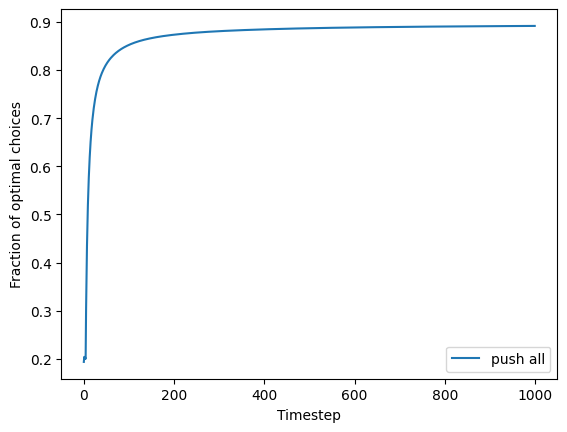

In [97]:
n_levers=5
timesteps = 1000 
metric_saver_push_all = np.zeros(timesteps)
n_runs = 2000


for i in (range(n_runs)):
    # initialization of algorithm (re-extract the bandits every time)
    q_star = np.random.normal(0, 5, n_levers)
    std_star = np.random.uniform(0.5, 2.5, n_levers)
    Q = np.zeros(n_levers)
    N = np.zeros(n_levers)
    
    best_action = np.argmax(q_star)
    actions = np.zeros(timesteps) # save the actions
    # loop
    for t in (range(timesteps)):
        a_idx = greedy_algorithm_with_first_push(Q,t)   # pick an action
        N[a_idx] += 1                                   # increase the counter for that action
        R = reward_generator_new(a_idx,q_star,std_star) # generate the reward
        Q = update_Q(Q,N,a_idx,R)                       # update Q
        actions[t] = a_idx
    
    # convert actions array in cumulative times of best action taken
    metric = optimal_action_metric(actions,best_action)
    metric_saver_push_all = metric_saver_push_all + (metric - metric_saver_push_all)/(i+1)
    
plt.plot(np.arange(0,timesteps,1),metric_saver_push_all,label='push all')
# plt.plot(np.arange(0,timesteps,1), avg_fraction_curve_elbo,label='variational inference')
plt.xlabel('Timestep')
plt.ylabel('Fraction of optimal choices')
plt.legend()
plt.show()


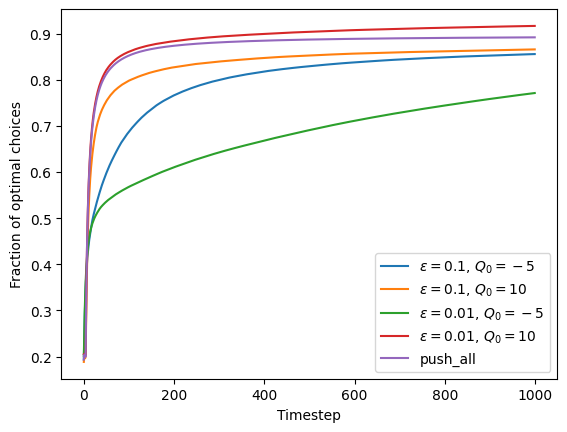

In [98]:
timesteps = 1000 
n_runs = 2000
epsilons = [0.1,0.01]
Q_zeros = [-5,10]
metric_saver_egoiv_vector=[]

for epsilon in epsilons:
    for q_zero in Q_zeros:
        metric_saver_egoiv = np.zeros(timesteps)
        for i in (range(n_runs)):
            # initialization of algorithm (re-extract the bandits every time)
            q_star = np.random.normal(0, 5, n_levers)
            std_star = np.random.uniform(0.5, 2.5, n_levers)

            if q_zero == 0:
                Q = np.zeros(n_levers)
            else:
                Q = np.ones(n_levers)*q_zero # optimistic initialization
            N = np.zeros(n_levers)
            
            best_action = np.argmax(q_star)
            actions = np.zeros(timesteps) # save the actions
            # loop
            for t in (range(timesteps)):
                a_idx = epsilon_greedy_algorithm(Q,epsilon)   # pick an action
                N[a_idx] += 1                                   # increase the counter for that action
                R = reward_generator_new(a_idx,q_star,std_star)          # generate the reward
                Q = update_Q(Q,N,a_idx,R)                       # update Q
                actions[t] = a_idx
            
            # convert actions array in cumulative times of best action taken
            metric = optimal_action_metric(actions,best_action)
            metric_saver_egoiv = metric_saver_egoiv + (metric - metric_saver_egoiv)/(i+1)
        metric_saver_egoiv_vector.append(metric_saver_egoiv)
            
        plt.plot(np.arange(0,timesteps,1),metric_saver_egoiv, label = f'$\epsilon = {epsilon}$, $Q_0 = {q_zero}$')
plt.plot(np.arange(0,timesteps,1),metric_saver_push_all, label = 'push_all')
# plt.plot(np.arange(0,timesteps,1), avg_fraction_curve_elbo,label='variational inference')
plt.xlabel('Timestep')
plt.ylabel('Fraction of optimal choices')
plt.legend()
plt.show()

    

/tmp/ipykernel_20711/3136958740.py:2: RuntimeWarning: divide by zero encountered in log
  a_idx = np.argmax(Q + c*np.sqrt(np.log(t)/N)) # argmax of this is the desired index
/tmp/ipykernel_20711/3136958740.py:2: RuntimeWarning: invalid value encountered in sqrt
  a_idx = np.argmax(Q + c*np.sqrt(np.log(t)/N)) # argmax of this is the desired index


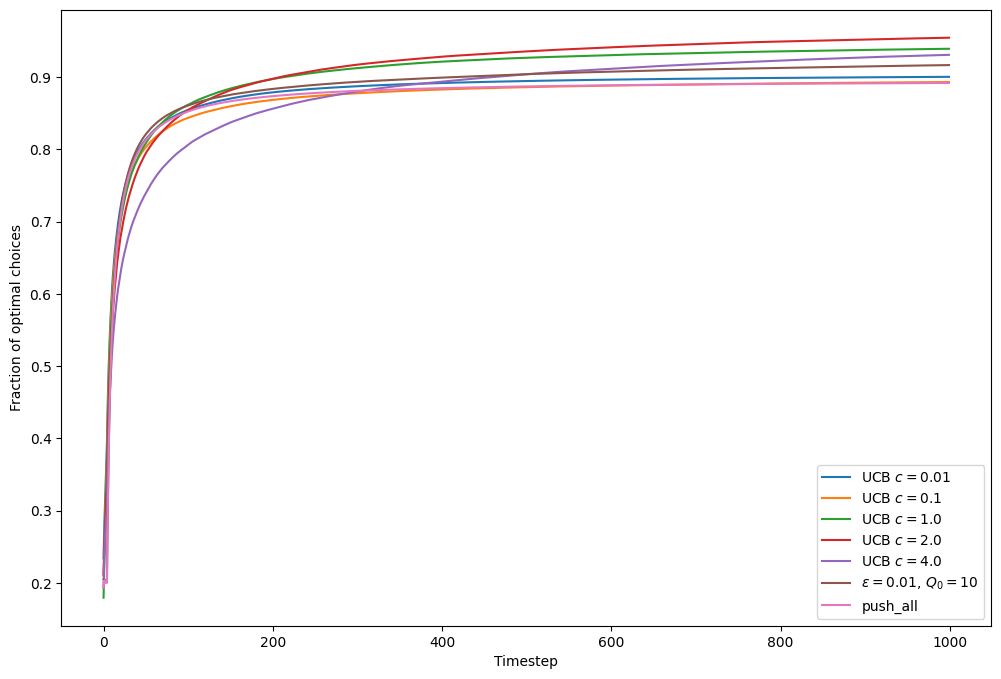

In [105]:
# initialization of Nruns
timesteps = 1000 # for how long the agent must play the bandit
n_runs = 2000
c_s = [0.01,0.1,1.,2.,4.]
metric_saver_UCB_vector=[]

plt.figure(figsize=(12,8))

for c in c_s:
    metric_saver_UCB = np.zeros(timesteps)
    for i in (range(n_runs)):
        # initialization of algorithm (re-extract the bandits every time)
        q_star = np.random.normal(0, 5, n_levers)
        std_star = np.random.uniform(0.5, 2.5, n_levers)

        Q = np.zeros(n_levers)
        N = np.ones(n_levers)   # avoid division by 0
            
        best_action = np.argmax(q_star)
        actions = np.zeros(timesteps) # save the actions
        
        for t in (range(timesteps)):
            a_idx = UCB_algorithm(Q,c,N,t)                  # picks the action
            N[a_idx] += 1                                   # increase the counter for that action
            R = reward_generator_new(a_idx,q_star,std_star)          # generate the reward
            Q = update_Q(Q,N,a_idx,R)                       # update Q
            actions[t] = a_idx
            
        # convert actions array in cumulative times of best action taken
        metric = optimal_action_metric(actions,best_action)
        metric_saver_UCB = metric_saver_UCB + (metric - metric_saver_UCB)/(i+1)
    metric_saver_UCB_vector.append(metric_saver_UCB)
    plt.plot(np.arange(0,timesteps,1),metric_saver_UCB, label = f'UCB $c = {c}$')
        
plt.plot(np.arange(0,timesteps,1),metric_saver_egoiv_vector[3], label = f'$\epsilon = 0.01$, $Q_0 = 10$')
plt.plot(np.arange(0,timesteps,1),metric_saver_push_all, label = 'push_all')
# plt.plot(np.arange(0,timesteps,1),avg_fraction_curve_elbo,label='variational inference')
plt.xlabel('Timestep')
plt.ylabel('Fraction of optimal choices')
plt.legend(loc='best')
plt.show()

    

In [106]:
push_all_regret=regret(np.arange(0,timesteps,1), metric_saver_push_all,timesteps)
egoiv_regret=[regret(np.arange(0,timesteps,1), metric_saver_egoiv_vector[i],timesteps) for i in range(len(metric_saver_egoiv_vector))]
UCB_regret=[regret(np.arange(0,timesteps,1), metric_saver_UCB_vector[i],timesteps) for i in range(len(metric_saver_UCB_vector))]

In [107]:
print(f'Push all: {push_all_regret} \n'
      f'Optimistic Intial Values: {egoiv_regret} \n'
      f'UCB:{UCB_regret} \n'
      f'Variational Inference:{mean_regret}' )

Push all: 0.13003158265413778 
Optimistic Intial Values: [0.20603744715905567, 0.16723642138539013, 0.3265860720818421, 0.11375652412804971] 
UCB:[0.12201541383001085, 0.13095030049658407, 0.09552472590596983, 0.08932903721831667, 0.1229800778701748] 
Variational Inference:0.256
